In [5]:
from click import style
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
# from active_simulation.bitrate_simulator import df_results

In [6]:
#df_results = pd.read_csv('results/threshold_finder_test.20250210110914.csv')
#df_results = pd.read_csv('results/threshold_finder_test.20250211064222.csv')

df_results_dqn = pd.read_csv('results/threshold_finder_test.dqn.20250521160129.csv')
df_results_ppo = pd.read_csv('results/threshold_finder_test.ppo.20250521160227.csv')
df_results_grpo = pd.read_csv('results/threshold_finder_test.grpo.20250521160305.csv')

df_results_dqn['Algorithm'] = 'DQN'
df_results_ppo['Algorithm'] = 'PPO'
df_results_grpo['Algorithm'] = 'GRPO'


In [7]:
def extract_success(df_results):
    success = []
    for _, row in df_results.iterrows():
        if row["New Selected Bitrate (kbps)"] > row["Original Selected Bitrate (kbps)"] and row["New Selected Bitrate (kbps)"] >= 15000:
            success.append("succeeded")
        elif row["New Selected Bitrate (kbps)"] < row["Original Selected Bitrate (kbps)"] and row["New Selected Bitrate (kbps)"] >= 15000:
            success.append("succeeded")
        elif row["New Selected Bitrate (kbps)"] > row["Original Selected Bitrate (kbps)"] and row["New Selected Bitrate (kbps)"] < 15000:
            success.append("partially successful")
        elif row["New Throughput (kbps)"] > row["Original Throughput (kbps)"] and row["New Selected Bitrate (kbps)"] < 15000:
            success.append("partially successful")
        elif row["New Throughput (kbps)"] > row["Original Throughput (kbps)"] and row["Original Selected Bitrate (kbps)"] >= 15000:
            success.append("succeeded")
        else:
            success.append("unsuccessful")

    df_results["success"] = success
    return df_results

In [8]:
df_results_dqn = extract_success(df_results_dqn)
df_results_ppo = extract_success(df_results_ppo)
df_results_grpo = extract_success(df_results_grpo)


In [9]:
df_results_dqn

,Original Network Latency,Original Computing Latency,Original Throughput (kbps),Original Selected Bitrate (kbps),Original Resolution,Recommended Action,New Network Latency,New Computing Latency,New Throughput (kbps),New Selected Bitrate (kbps),New Resolution,Algorithm,success
0,1.146999,1.196435,14318.487779,8000,1080p,Decrease Both Latencies,0.861712,0.911148,18926.723034,15000,1440p,DQN,succeeded
1,1.058682,0.763148,18417.978599,15000,1440p,Decrease Computing Latency,1.058682,0.637486,19782.491918,15000,1440p,DQN,succeeded
2,0.898589,1.239217,15695.728878,15000,1440p,Decrease Network Latency,0.681991,1.239217,17465.281593,15000,1440p,DQN,succeeded
3,1.666967,1.460555,10728.761971,8000,1080p,Keep Latency,1.666967,1.460555,10728.761971,8000,1080p,DQN,unsuccessful
4,1.268520,1.705451,11282.702862,8000,1080p,Keep Latency,1.268520,1.705451,11282.702862,8000,1080p,DQN,unsuccessful
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.807119,0.934379,19267.574550,15000,1440p,Decrease Computing Latency,0.807119,0.828354,20516.664323,15000,1440p,DQN,succeeded
9996,1.589209,1.117568,12396.451792,8000,1080p,Keep Latency,1.589209,1.117568,12396.451792,8000,1080p,DQN,unsuccessful
9997,1.972074,1.850166,8778.735011,8000,1080p,Keep Latency,1.972074,1.850166,8778.735011,8000,1080p,DQN,unsuccessful
9998,1.819051,2.119117,8520.313432,8000,1080p,Keep Latency,1.819051,2.119117,8520.313432,8000,1080p,DQN,unsuccessful


/var/folders/jc/mjq2pm711vs56qvyw_hpxxp00000gp/T/ipykernel_41791/3975480937.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=16)


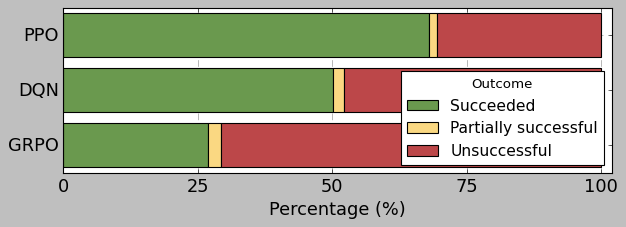

In [84]:
# Count success types
methods = {
    "GRPO": df_results_grpo,
    "DQN": df_results_dqn,
    "PPO": df_results_ppo
}

categories = ["succeeded", "partially successful", "unsuccessful"]
colors = {
    "succeeded": "#6A994E",
    "partially successful": "#FAD882",
    "unsuccessful": "#BC4749"
}

# Compute percentages
percent_data = {}
for method, df in methods.items():
    total = len(df)
    percent_data[method] = {
        cat: (df["success"] == cat).sum() / total * 100 for cat in categories
    }

# Prepare data for plotting
labels = list(percent_data.keys())
data = {cat: [percent_data[m][cat] for m in labels] for cat in categories}

plt.style.use('classic')
# Plot
fig, ax = plt.subplots(figsize=(8, 3))
left = [0] * len(labels)

for cat in categories:
    ax.barh(labels, data[cat], left=left, label=cat.capitalize(), color=colors[cat])
    left = [sum(x) for x in zip(left, data[cat])]


ax.set_xticks([0,25,50,75,100])
ax.set_xticklabels([0,25,50,75,100], fontsize=16)
ax.set_xlabel("Percentage (%)", fontsize=16)
ax.set_xlim(0, 102)

ax.set_yticklabels(labels, fontsize=16)
ax.set_ylim(-0.5, 2.5)

#ax.set_title("Success Rate per Method (Stacked)")
ax.set_axisbelow(True)
ax.grid(color='gray', linestyle='dashed')

ax.legend(title="Outcome", loc='lower right', fontsize=14)

plt.tight_layout()
plt.savefig('figures/threshold_finder_test_results.pdf', format='pdf')

In [11]:
data_path = "../data/simulations/throughput_bitrate/throughput_bitrate.20250209181231.csv"

In [12]:
train_data = pd.read_csv(data_path)

In [13]:
train_data

,Total Network Latency (s),Total Computing Latency (s),Throughput (kbps),Selected Bitrate (kbps),Resolution
0,1.305188,1.150506,13663.929522,8000,1080p
1,0.759770,0.660001,23633.690424,15000,1440p
2,1.648486,1.290679,11416.315431,8000,1080p
3,1.239943,0.947703,15338.150964,15000,1440p
4,1.417195,1.547000,11319.912086,8000,1080p
...,...,...,...,...,...
995,1.237964,1.150030,14051.303513,8000,1080p
996,1.633059,1.378609,11141.476394,8000,1080p
997,1.043901,0.950041,16828.181682,15000,1440p
998,1.540430,1.224459,12135.904858,8000,1080p


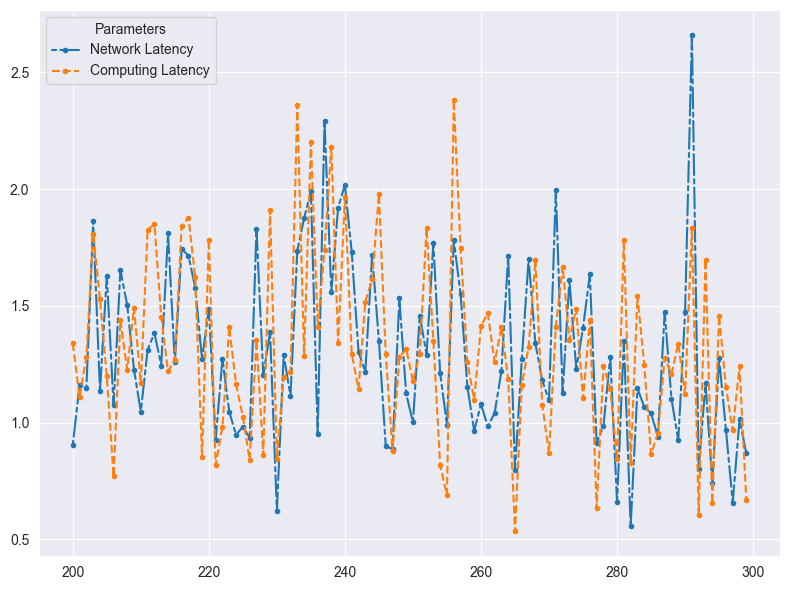

In [14]:

fig, ax = plt.subplots(figsize=(8, 6))

# Using set_dashes() and set_capstyle() to modify dashing of an existing line.
line1, = ax.plot(np.arange(200, 300), train_data["Total Network Latency (s)"][200:300], '.', label="Network Latency")
line1.set_dashes([2, 2, 10, 2])  # 2pt line, 2pt break, 10pt line, 2pt break.
line1.set_dash_capstyle('round')

line2, = ax.plot(np.arange(200, 300), train_data["Total Computing Latency (s)"][200:300], '.--', label="Computing Latency")


ax.legend(title="Parameters")

#plt.show()
plt.tight_layout()
plt.savefig('figures/sample_train_latencies.pdf', format='pdf')



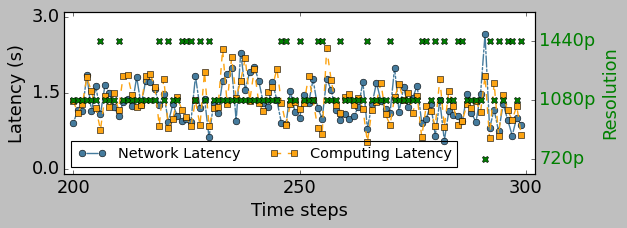

In [171]:
fig, ax1 = plt.subplots(figsize=(8, 3))

# First y-axis - Latency data
line1, = ax1.plot(np.arange(200, 300), train_data["Total Network Latency (s)"][200:300], 'o', linewidth=1.25,
                  label="Network Latency", color='#457b9d')
line1.set_dashes([2, 2, 10, 2])
line1.set_dash_capstyle('round')

line2, = ax1.plot(np.arange(200, 300), train_data["Total Computing Latency (s)"][200:300], 's--', linewidth=1.25,
                  label="Computing Latency", color='#fca311')

ax1.set_ylabel('Latency (s)', color='black', fontsize=16)
ax1.set_yticks([0., 1.5, 3.0])
ax1.set_yticklabels([0., 1.5, 3.0], fontsize=16)
ax1.set_ylim(-0.1, 3.1)

ax1.set_xlabel('Time steps', fontsize=16)

ax1.set_xticks([200, 250, 300])
ax1.set_xticklabels([200, 250, 300], fontsize=16)
ax1.set_xlim(198, 302)

legend1 = ax1.legend(loc='lower left', ncol=2, fontsize=13)
legend1.get_frame().set_facecolor('none')


# Second y-axis - Resolution data
ax2 = ax1.twinx()

# Define resolution order: 720p=0 (bottom), 1080p=1 (middle), 1440p=2 (top)
resolution_order = ['720p', '1080p', '1440p']
resolution_mapping = {
    '720p': 0,    # Lowest position
    '1080p': 1,   # Middle position
    '1440p': 2    # Highest position
}

resolution_data = train_data["Resolution"][200:300]
resolution_numeric = [resolution_mapping.get(res, 1) for res in resolution_data]  # Default to 1080p if unknown

line3, = ax2.plot(np.arange(200, 300), resolution_numeric, 'X', color='green', label="Resolution") #, markersize=4, mew=1.5)

# Set up the categorical y-axis
ax2.set_ylabel('Resolution', color='green', fontsize=16)
ax2.set_yticks([0, 1, 2])  # Positions for 720p, 1080p, 1440p
ax2.set_yticklabels(['720p', '1080p', '1440p'], fontsize=16)
ax2.set_ylim(-0.25, 2.5)

ax2.tick_params(axis='y', labelcolor='green')
#legend2 = ax2.legend(loc='upper right', fontsize=14)
#legend2.get_frame().set_facecolor('none')

plt.tight_layout()
plt.savefig('figures/sample_train_latencies.pdf', format='pdf')

In [16]:
partial_df = df_results_dqn.join(df_results_ppo, lsuffix='_dqn', rsuffix='_ppo')
final_df = partial_df.join(df_results_grpo, rsuffix='_grpo')

In [17]:
final_df

,Original Network Latency_dqn,Original Computing Latency_dqn,Original Throughput (kbps)_dqn,Original Selected Bitrate (kbps)_dqn,Original Resolution_dqn,Recommended Action_dqn,New Network Latency_dqn,New Computing Latency_dqn,New Throughput (kbps)_dqn,New Selected Bitrate (kbps)_dqn,...,Original Selected Bitrate (kbps),Original Resolution,Recommended Action,New Network Latency,New Computing Latency,New Throughput (kbps),New Selected Bitrate (kbps),New Resolution,Algorithm,success
0,1.146999,1.196435,14318.487779,8000,1080p,Decrease Both Latencies,0.861712,0.911148,18926.723034,15000,...,8000,1080p,Decrease Both Latencies,0.861712,0.911148,18926.723034,15000,1440p,GRPO,succeeded
1,1.058682,0.763148,18417.978599,15000,1440p,Decrease Computing Latency,1.058682,0.637486,19782.491918,15000,...,15000,1440p,Keep Latency,1.058682,0.763148,18417.978599,15000,1440p,GRPO,unsuccessful
2,0.898589,1.239217,15695.728878,15000,1440p,Decrease Network Latency,0.681991,1.239217,17465.281593,15000,...,15000,1440p,Keep Latency,0.898589,1.239217,15695.728878,15000,1440p,GRPO,unsuccessful
3,1.666967,1.460555,10728.761971,8000,1080p,Keep Latency,1.666967,1.460555,10728.761971,8000,...,8000,1080p,Keep Latency,1.666967,1.460555,10728.761971,8000,1080p,GRPO,unsuccessful
4,1.268520,1.705451,11282.702862,8000,1080p,Keep Latency,1.268520,1.705451,11282.702862,8000,...,8000,1080p,Keep Latency,1.268520,1.705451,11282.702862,8000,1080p,GRPO,unsuccessful
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.807119,0.934379,19267.574550,15000,1440p,Decrease Computing Latency,0.807119,0.828354,20516.664323,15000,...,15000,1440p,Keep Latency,0.807119,0.934379,19267.574550,15000,1440p,GRPO,unsuccessful
9996,1.589209,1.117568,12396.451792,8000,1080p,Keep Latency,1.589209,1.117568,12396.451792,8000,...,8000,1080p,Decrease Both Latencies,1.170196,0.698554,17955.545342,15000,1440p,GRPO,succeeded
9997,1.972074,1.850166,8778.735011,8000,1080p,Keep Latency,1.972074,1.850166,8778.735011,8000,...,8000,1080p,Keep Latency,1.972074,1.850166,8778.735011,8000,1080p,GRPO,unsuccessful
9998,1.819051,2.119117,8520.313432,8000,1080p,Keep Latency,1.819051,2.119117,8520.313432,8000,...,8000,1080p,Keep Latency,1.819051,2.119117,8520.313432,8000,1080p,GRPO,unsuccessful


In [18]:
# Prepare data for violin plots
def prepare_violin_data(df_dqn, df_ppo, df_grpo, original_col, new_col):
    """Prepare data for violin plots by combining all datasets"""
    data = []

    # Original data (same for all models, so we'll use DQN as reference)
    for val in df_dqn[original_col]:
        data.append({'Latency': val, 'Method': 'Original', 'Type': original_col.replace('Original ', '')})

    # DQN new data
    for val in df_dqn[new_col]:
        data.append({'Latency': val, 'Method': 'DQN', 'Type': new_col.replace('New ', '')})

    # PPO new data
    for val in df_ppo[new_col]:
        data.append({'Latency': val, 'Method': 'PPO', 'Type': new_col.replace('New ', '')})

    # GRPO new data
    for val in df_grpo[new_col]:
        data.append({'Latency': val, 'Method': 'GRPO', 'Type': new_col.replace('New ', '')})

    return pd.DataFrame(data)


In [19]:

network_data = prepare_violin_data(df_results_dqn, df_results_ppo, df_results_grpo,
                                 'Original Network Latency', 'New Network Latency')
computing_data = prepare_violin_data(df_results_dqn, df_results_ppo, df_results_grpo,
                                   'Original Computing Latency', 'New Computing Latency')

In [20]:
network_data

,Latency,Method,Type
0,1.146999,Original,Network Latency
1,1.058682,Original,Network Latency
2,0.898589,Original,Network Latency
3,1.666967,Original,Network Latency
4,1.268520,Original,Network Latency
...,...,...,...
39995,0.807119,GRPO,Network Latency
39996,1.170196,GRPO,Network Latency
39997,1.972074,GRPO,Network Latency
39998,1.819051,GRPO,Network Latency


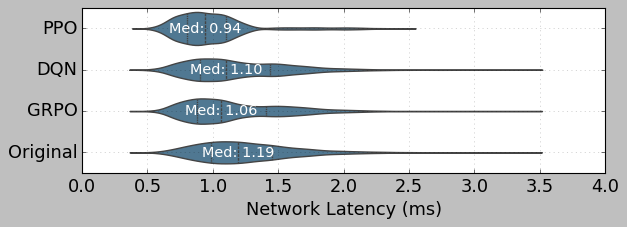

In [104]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(data=network_data, x='Latency', y='Method', ax=ax, order=['PPO', 'DQN', 'GRPO', 'Original'], color='#457b9d', inner='quartile')
#ax1.set_title('Network Latency Distribution Comparison', fontsize=16, fontweight='bold', pad=20)
#ax1.set_xlabel('RL Method', fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Network Latency (ms)', fontsize=16) #, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, alpha=0.3)

# add statistics annotations for network latency
methods = ['PPO', 'DQN', 'GRPO', 'Original']
for i, method in enumerate(methods):
    subset = network_data[network_data['Method'] == method]
    median_val = subset['Latency'].median()
    ax.text(median_val, i, f'Med: {median_val:.2f}',
             ha='center', va='center', fontweight='normal', fontsize=13, color='white')

plt.tight_layout()

plt.savefig('figures/rl_network_latency_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/rl_network_latency_comparison.pdf', format='pdf')

plt.show()

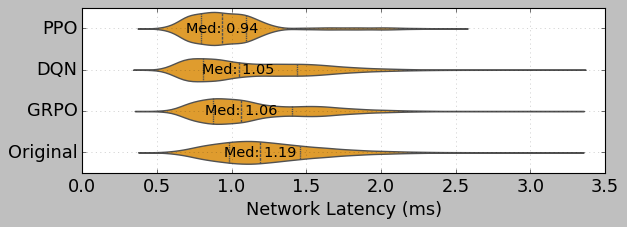

In [103]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(data=computing_data, x='Latency', y='Method', ax=ax, order=['PPO', 'DQN', 'GRPO', 'Original'], color='#fca311', inner='quartile')
#ax1.set_title('Network Latency Distribution Comparison', fontsize=16, fontweight='bold', pad=20)
#ax1.set_xlabel('RL Method', fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Network Latency (ms)', fontsize=16) #, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, alpha=0.3)

# add statistics annotations for network latency
methods = ['PPO', 'DQN', 'GRPO', 'Original']
for i, method in enumerate(methods):
    subset = computing_data[computing_data['Method'] == method]
    median_val = subset['Latency'].median()
    ax.text(median_val, i, f'Med: {median_val:.2f}',
             ha='center', va='center', fontweight='normal', fontsize=13)

plt.tight_layout()


# Optional: Save the plots
plt.savefig('figures/rl_computing_latency_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/rl_computing_latency_comparison.pdf', format='pdf')

plt.show()

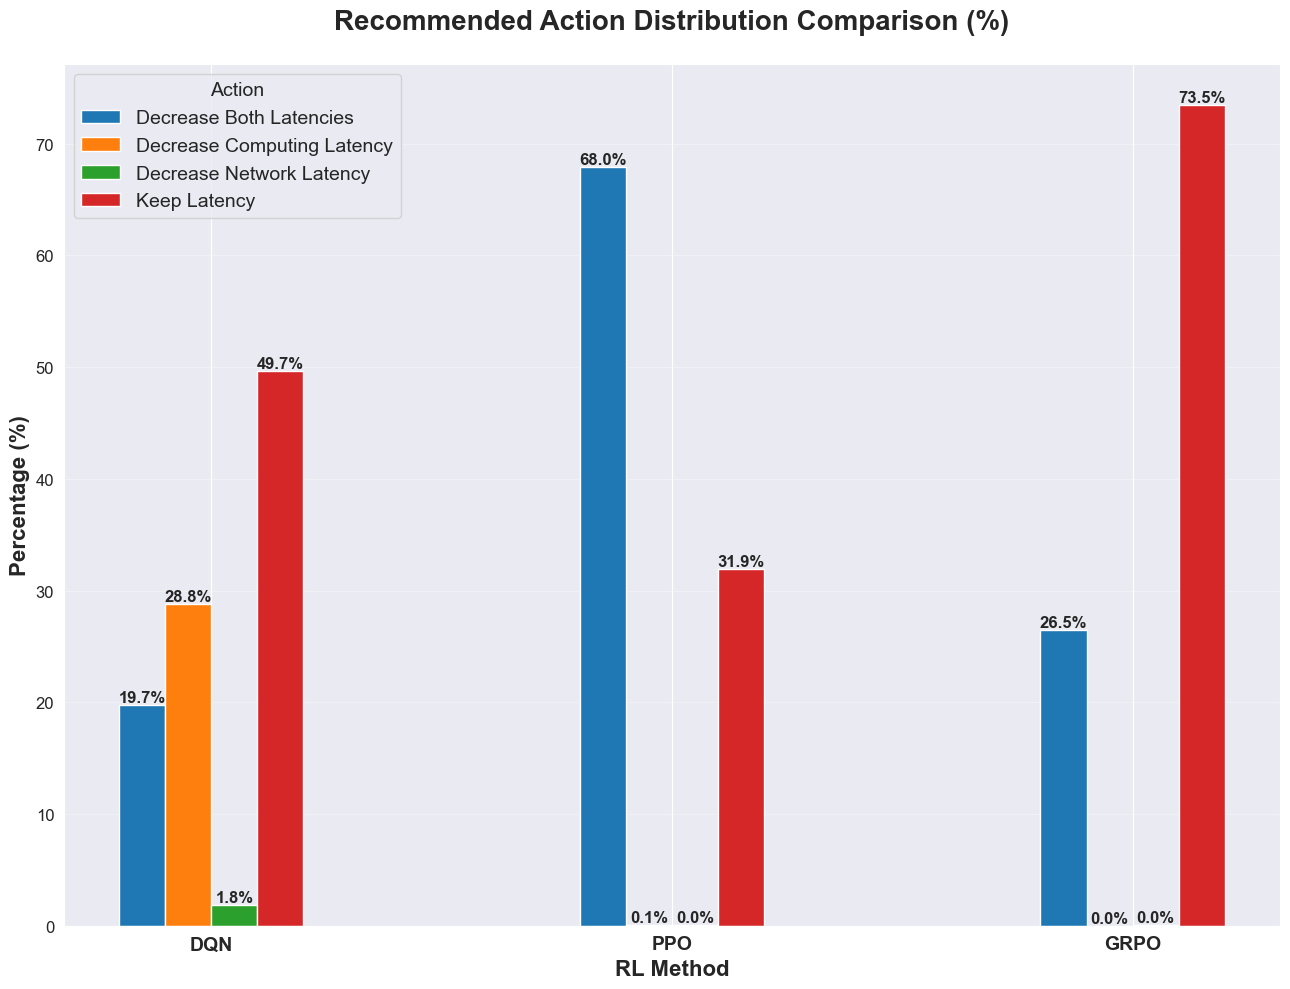

In [23]:
"""Create a stacked percentage bar chart for action comparison"""
fig4, ax4 = plt.subplots(figsize=(13, 10))

# Calculate percentages for each method
dqn_pct = df_results_dqn['Recommended Action'].value_counts(normalize=True) * 100
ppo_pct = df_results_ppo['Recommended Action'].value_counts(normalize=True) * 100
grpo_pct = df_results_grpo['Recommended Action'].value_counts(normalize=True) * 100

# Get all unique actions
all_actions = sorted(set(list(dqn_pct.index) + list(ppo_pct.index) + list(grpo_pct.index)))

# Create data for plotting
methods = ['DQN', 'PPO', 'GRPO']
percentages = {action: [] for action in all_actions}

for action in all_actions:
    percentages[action].append(dqn_pct.get(action, 0))
    percentages[action].append(ppo_pct.get(action, 0))
    percentages[action].append(grpo_pct.get(action, 0))

# Create grouped bar chart with more spacing
x = np.arange(len(methods)) * 1.5  # Increase spacing between methods
width = 0.15  # Slightly narrower bars for better spacing
multiplier = 0

for action, pct_values in percentages.items():
    offset = width * multiplier
    bars = ax4.bar(x + offset, pct_values, width, label=action)
    ax4.bar_label(bars, fmt='%.1f%%', fontsize=12, fontweight='bold')
    multiplier += 1

ax4.set_title('Recommended Action Distribution Comparison (%)', fontsize=20, fontweight='bold', pad=25)
ax4.set_ylabel('Percentage (%)', fontsize=16, fontweight='bold')
ax4.set_xlabel('RL Method', fontsize=16, fontweight='bold')
ax4.set_xticks(x + width * (len(all_actions) - 1) / 2)
ax4.set_xticklabels(methods, fontsize=14, fontweight='bold')
ax4.tick_params(axis='y', labelsize=12)
ax4.legend(title='Action', loc='upper left', #bbox_to_anchor=(1.05, 1),
           fontsize=14, title_fontsize=14)
ax4.grid(True, alpha=0.3, axis='y')
plt.savefig('figures/rl_recommended_action_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/rl_recommended_action_comparison.pdf', format='pdf', bbox_inches='tight')
plt.tight_layout()

/var/folders/jc/mjq2pm711vs56qvyw_hpxxp00000gp/T/ipykernel_41791/133681625.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=16)


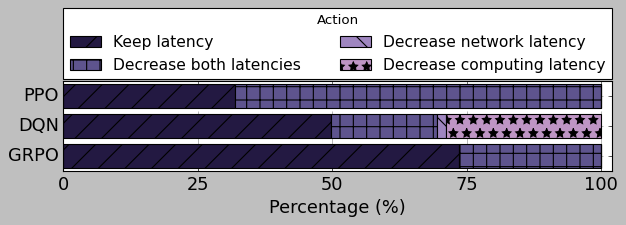

In [145]:
# Count success types
methods = {
    "GRPO": df_results_grpo,
    "DQN": df_results_dqn,
    "PPO": df_results_ppo
}

categories = ["Keep Latency", "Decrease Both Latencies", "Decrease Network Latency", "Decrease Computing Latency"]
colors = {
    "Keep Latency": "#231942",
    "Decrease Both Latencies": "#5E548E",
    "Decrease Network Latency": "#9F86C0",
    "Decrease Computing Latency": "#BE95C4",
}

patterns = {
    "Keep Latency": "/",
    "Decrease Both Latencies": "+",
    "Decrease Network Latency": "\\",
    "Decrease Computing Latency": "*",
}

# Compute percentages
percent_data = {}
for method, df in methods.items():
    total = len(df)
    percent_data[method] = {
        cat: (df["Recommended Action"] == cat).sum() / total * 100 for cat in categories
    }

# Prepare data for plotting
labels = list(percent_data.keys())
data = {cat: [percent_data[m][cat] for m in labels] for cat in categories}

#plt.style.use('classic')
# Plot
fig, ax = plt.subplots(figsize=(8, 3))
left = [0] * len(labels)

for cat in categories:
    ax.barh(labels, data[cat], left=left, label=cat.capitalize(), color=colors[cat], hatch=patterns[cat])
    left = [sum(x) for x in zip(left, data[cat])]


ax.set_xticks([0,25,50,75,100])
ax.set_xticklabels([0,25,50,75,100], fontsize=16)
ax.set_xlabel("Percentage (%)", fontsize=16)
ax.set_xlim(0, 102)

ax.set_yticklabels(labels, fontsize=16)
ax.set_ylim(-0.5, 2.5)

#ax.set_title("Success Rate per Method (Stacked)")
ax.set_axisbelow(True)
ax.grid(color='gray', linestyle='dashed')

ax.legend(title="Action", fontsize=14,ncol=2, bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', mode="expand", borderaxespad=0.)

plt.tight_layout()
plt.savefig('figures/rl_recommended_action_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/rl_recommended_action_comparison.pdf', format='pdf', bbox_inches='tight')

In [24]:
# Define helper functions
def calculate_total_latency(df):
    """Calculate total latency (network + computing)"""
    df['Original_Total_Latency'] = df['Original Network Latency'] + df['Original Computing Latency']
    df['New_Total_Latency'] = df['New Network Latency'] + df['New Computing Latency']
    return df

def create_latency_buckets(latency_values, n_buckets=5):
    """Create latency buckets"""
    min_val, max_val = latency_values.min(), latency_values.max()
    bucket_edges = np.linspace(min_val, max_val, n_buckets + 1)
    bucket_labels = [f'{bucket_edges[i]:.1f}-{bucket_edges[i+1]:.1f}ms'
                    for i in range(len(bucket_edges)-1)]
    buckets = pd.cut(latency_values, bins=bucket_edges, labels=bucket_labels, include_lowest=True)
    return buckets



In [25]:
df_combined = pd.concat([df_results_dqn, df_results_ppo, df_results_grpo], ignore_index=True)

In [26]:
df_combined

,Original Network Latency,Original Computing Latency,Original Throughput (kbps),Original Selected Bitrate (kbps),Original Resolution,Recommended Action,New Network Latency,New Computing Latency,New Throughput (kbps),New Selected Bitrate (kbps),New Resolution,Algorithm,success
0,1.146999,1.196435,14318.487779,8000,1080p,Decrease Both Latencies,0.861712,0.911148,18926.723034,15000,1440p,DQN,succeeded
1,1.058682,0.763148,18417.978599,15000,1440p,Decrease Computing Latency,1.058682,0.637486,19782.491918,15000,1440p,DQN,succeeded
2,0.898589,1.239217,15695.728878,15000,1440p,Decrease Network Latency,0.681991,1.239217,17465.281593,15000,1440p,DQN,succeeded
3,1.666967,1.460555,10728.761971,8000,1080p,Keep Latency,1.666967,1.460555,10728.761971,8000,1080p,DQN,unsuccessful
4,1.268520,1.705451,11282.702862,8000,1080p,Keep Latency,1.268520,1.705451,11282.702862,8000,1080p,DQN,unsuccessful
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.807119,0.934379,19267.574550,15000,1440p,Keep Latency,0.807119,0.934379,19267.574550,15000,1440p,GRPO,unsuccessful
29996,1.589209,1.117568,12396.451792,8000,1080p,Decrease Both Latencies,1.170196,0.698554,17955.545342,15000,1440p,GRPO,succeeded
29997,1.972074,1.850166,8778.735011,8000,1080p,Keep Latency,1.972074,1.850166,8778.735011,8000,1080p,GRPO,unsuccessful
29998,1.819051,2.119117,8520.313432,8000,1080p,Keep Latency,1.819051,2.119117,8520.313432,8000,1080p,GRPO,unsuccessful


In [27]:
df_combined = calculate_total_latency(df_combined)
df_combined['Latency_Bucket'] = create_latency_buckets(df_combined['Original_Total_Latency'])

In [28]:
df_combined[:100].to_csv('rl_computing_latency_comparison.csv', index=False)

In [29]:
success_mapping = {'succeeded': 1, 'partially successful': 0.5, 'unsuccessful': 0}
df_combined['success_numeric'] = df_combined['success'].map(success_mapping)


/var/folders/jc/mjq2pm711vs56qvyw_hpxxp00000gp/T/ipykernel_41791/2884422819.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_success = df_combined.groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()


Text(0.5, 1.0, 'Action Success Rate by Latency Range')

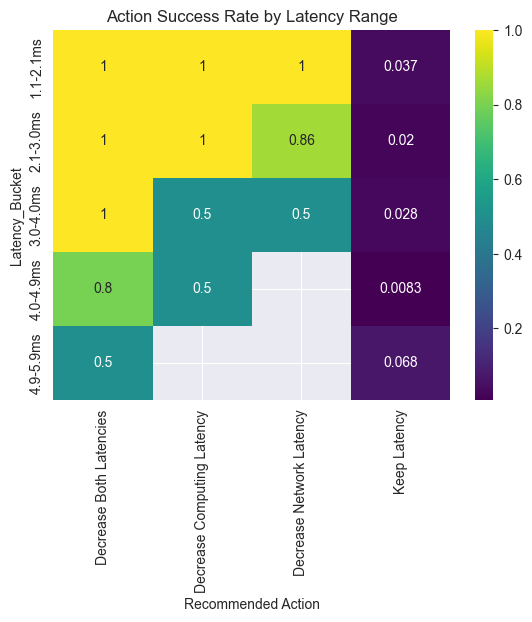

In [30]:
mean_success = df_combined.groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()
sns.heatmap(mean_success, annot=True, cmap='viridis')
plt.title('Action Success Rate by Latency Range')

/var/folders/jc/mjq2pm711vs56qvyw_hpxxp00000gp/T/ipykernel_41791/3715239342.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_success_dqn = df_combined[df_combined['Algorithm'] == 'DQN'].groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()


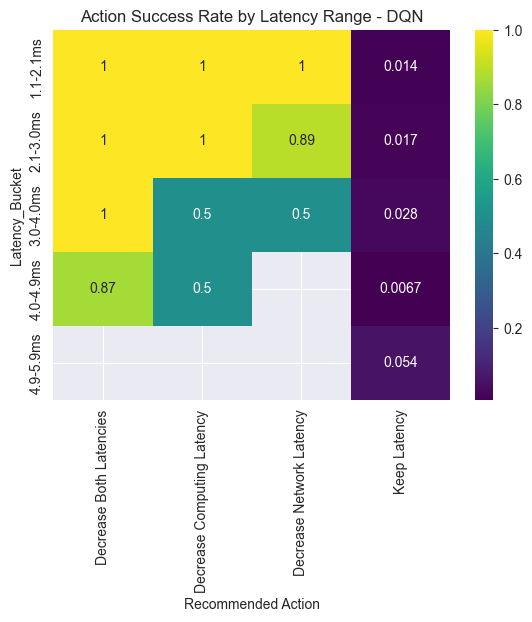

In [31]:
mean_success_dqn = df_combined[df_combined['Algorithm'] == 'DQN'].groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()
sns.heatmap(mean_success_dqn, annot=True, cmap='viridis')
plt.title('Action Success Rate by Latency Range - DQN')

#plt.tight_layout()

plt.savefig('figures/action_success_rate_dqn.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/action_success_rate_dqn.pdf', format='pdf', bbox_inches='tight')

/var/folders/jc/mjq2pm711vs56qvyw_hpxxp00000gp/T/ipykernel_41791/3715811504.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_success_ppo = df_combined[df_combined['Algorithm'] == 'PPO'].groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()


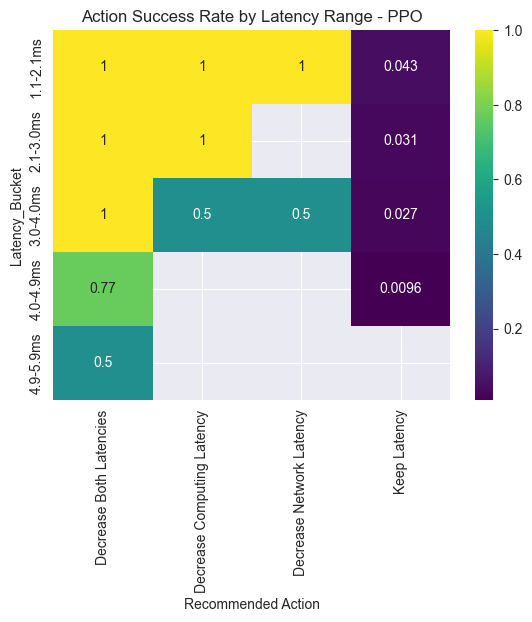

In [32]:
mean_success_ppo = df_combined[df_combined['Algorithm'] == 'PPO'].groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()
sns.heatmap(mean_success_ppo, annot=True, cmap='viridis')
plt.title('Action Success Rate by Latency Range - PPO')

plt.savefig('figures/action_success_rate_ppo.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/action_success_rate_ppo.pdf', format='pdf', bbox_inches='tight')

/var/folders/jc/mjq2pm711vs56qvyw_hpxxp00000gp/T/ipykernel_41791/1059697565.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_success_grpo = df_combined[df_combined['Algorithm'] == 'GRPO'].groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()


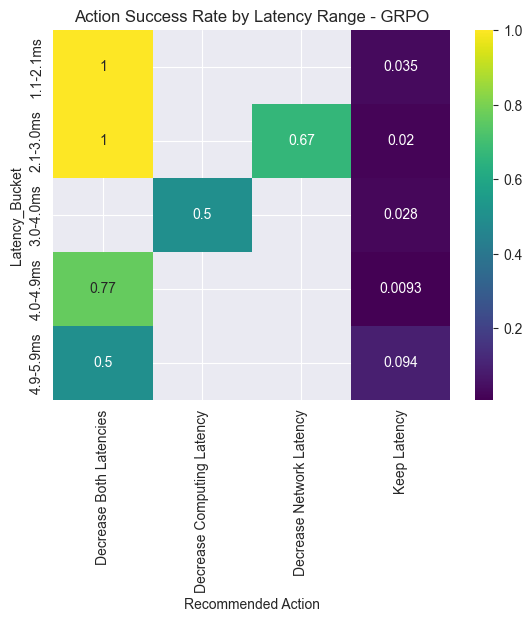

In [33]:
mean_success_grpo = df_combined[df_combined['Algorithm'] == 'GRPO'].groupby(['Latency_Bucket', 'Recommended Action'])['success_numeric'].mean().unstack()
sns.heatmap(mean_success_grpo, annot=True, cmap='viridis')
plt.title('Action Success Rate by Latency Range - GRPO')

plt.savefig('figures/action_success_rate_grpo.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/action_success_rate_grpo.pdf', format='pdf', bbox_inches='tight')

In [34]:
df_reward_dqn = pd.read_csv('logs/dqn_monitor_20250611_163726.monitor.csv', skiprows=1)
df_reward_ppo = pd.read_csv('logs/ppo_monitor_20250611_164444.monitor.csv', skiprows=1)

df_reward_dqn['Algorithm'] = 'DQN'
df_reward_ppo['Algorithm'] = 'PPO'

df_total_reward = pd.concat([df_reward_dqn, df_reward_ppo])
df_total_reward['episode'] = df_total_reward.groupby('Algorithm').cumcount()

df_total_reward

,r,l,t,resolution,throughput,Algorithm,episode
0,-2364.0,10000,9.465764,1440p,16604.209892,DQN,0
1,-1648.0,10000,16.673995,1080p,9370.274637,DQN,1
2,-2120.0,10000,23.957186,1440p,18150.918795,DQN,2
3,-2552.0,10000,31.973429,1440p,16598.309868,DQN,3
4,-1932.0,10000,40.334952,1440p,19109.847297,DQN,4
5,-1872.0,10000,51.133413,1440p,15173.046430,DQN,5
6,-1084.0,10000,61.830307,1440p,15380.472103,DQN,6
7,-1228.0,10000,71.521784,1080p,14860.458273,DQN,7
8,-208.0,10000,81.752291,1440p,16231.776537,DQN,8
9,172.0,10000,91.497371,1440p,17643.800304,DQN,9


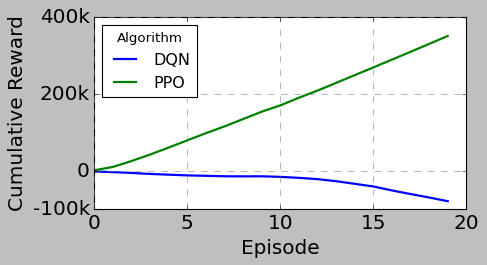

In [176]:
df_total_reward['cumulative_reward'] = df_total_reward.groupby('Algorithm')['r'].cumsum()
# Then, average across runs for each algorithm and episode
mean_rewards = df_total_reward.groupby(['Algorithm', 'episode'])['cumulative_reward'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 3))

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

sns.lineplot(
    data=mean_rewards,
    x='episode',
    y='cumulative_reward',
    hue='Algorithm',
    linewidth=2,
)
ax.set_xticks([0, 5, 10, 15,20])
ax.set_xticklabels([0, 5, 10, 15,20])

ax.set_yticks([-100000, 0, 200000, 400000])
ax.set_yticklabels(['-100k', '0', '200k', '400k'])

ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid(color='gray', linestyle='dashed')

plt.xlabel('Episode', fontsize=18)
plt.ylabel('Cumulative Reward', fontsize=18)



plt.legend(title='Algorithm', loc='upper left')

plt.savefig('figures/cumulative_reward_DQN-PPO.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/cumulative_reward_DQN-PPO.pdf', format='pdf', bbox_inches='tight')